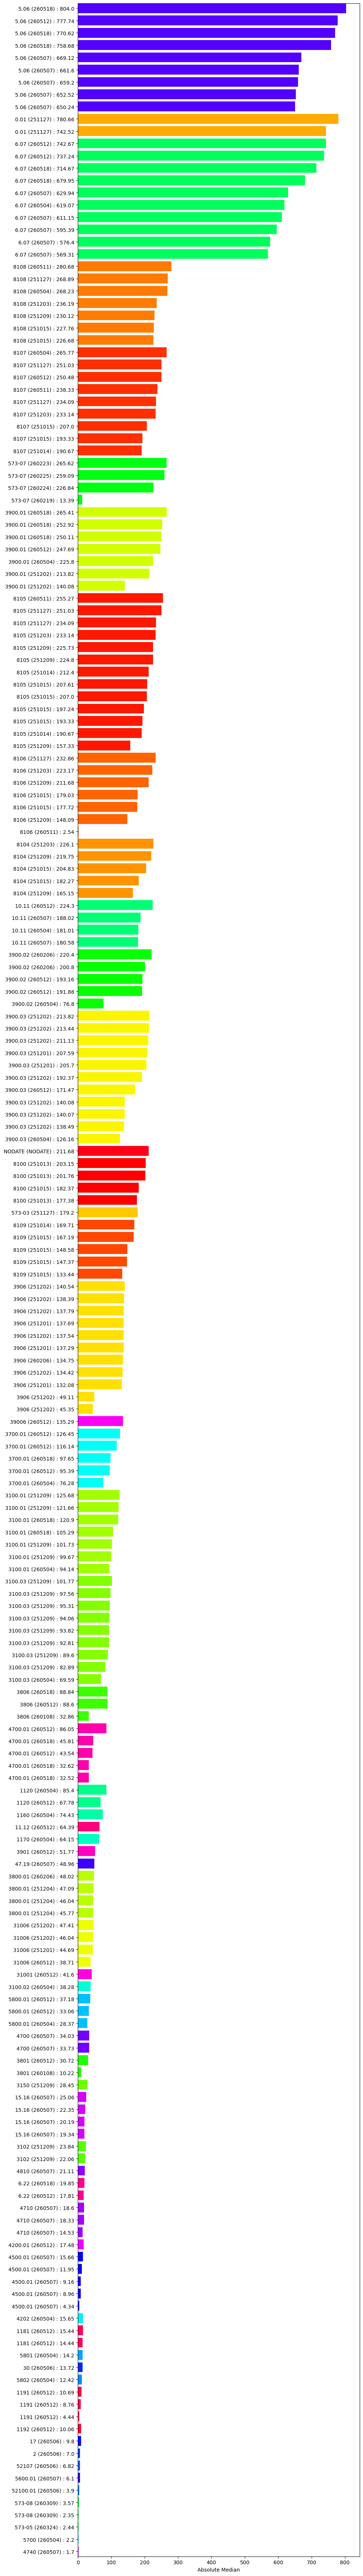

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


csv_path = r"c:\Users\ArnauCoronado\Documents_local\euromed\sxs\create\data\at_timeseries.csv"

df = pd.read_csv(csv_path, sep=",")

df = df.copy()

df["abs_Median"] = df["Median"].abs()
df = df.dropna(subset=["abs_Median"])
df = df[df["abs_Median"] > 1]

df["group_max"] = df.groupby("POINTNAME")["abs_Median"].transform("max")


df_sorted = df.sort_values(
    ["group_max", "abs_Median"],
    ascending=[False, False]
)

df_sorted["label"] = (
    df_sorted["POINTNAME"].astype(str)
    + " (" + df_sorted["DATE"].astype(str)
    + ") : "
    + df_sorted["abs_Median"].round(2).astype(str)
)

unique_points = df["POINTNAME"].unique()

colors = plt.cm.hsv(np.linspace(0, 1, len(unique_points)))
color_map = dict(zip(unique_points, colors))

bar_colors = df_sorted["POINTNAME"].map(color_map)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, max(2, len(df_sorted) * 0.3)))

plt.barh(
    df_sorted["label"],
    df_sorted["abs_Median"],
    color=bar_colors
)
plt.gca().invert_yaxis()
plt.xlabel("Absolute Median")
plt.tight_layout()
plt.margins(y=0)
plt.show()

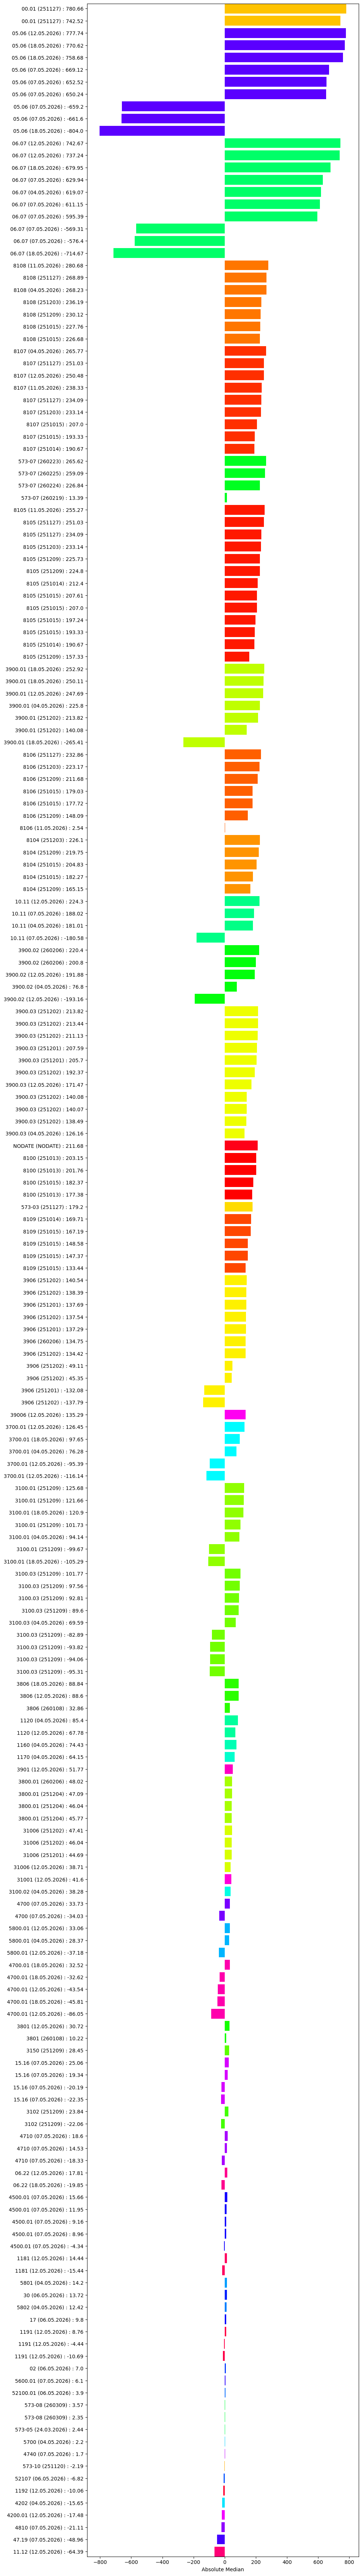

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


csv_path = r"c:\Users\ArnauCoronado\Documents_local\euromed\history\e_timeseries\timeseries_normalized_1.csv"

df = pd.read_csv(csv_path, sep=";")

df = df.copy()

df["abs_Median"] = df["Median"]
df = df.dropna(subset=["abs_Median"])
df = df[(df["Median"] > 1) | (df["Median"] < -1)]

df["group_max"] = df.groupby("POINTNAME")["abs_Median"].transform("max")


df_sorted = df.sort_values(
    ["group_max", "abs_Median"],
    ascending=[False, False]
)

df_sorted["label"] = (
    df_sorted["POINTNAME"].astype(str)
    + " (" + df_sorted["DATE"].astype(str)
    + ") : "
    + df_sorted["abs_Median"].round(2).astype(str)
)

unique_points = df["POINTNAME"].unique()

colors = plt.cm.hsv(np.linspace(0, 1, len(unique_points)))
color_map = dict(zip(unique_points, colors))

bar_colors = df_sorted["POINTNAME"].map(color_map)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, max(2, len(df_sorted) * 0.3)))

plt.barh(
    df_sorted["label"],
    df_sorted["abs_Median"],
    color=bar_colors
)
plt.gca().invert_yaxis()
plt.xlabel("Absolute Median")
plt.tight_layout()
plt.margins(y=0)
plt.show()

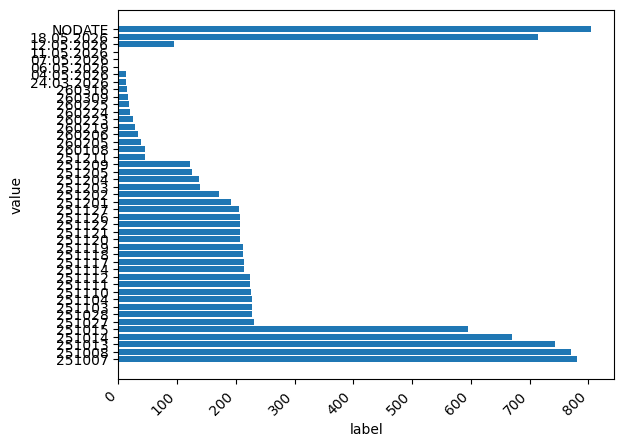

In [ ]:
median_list = df['Median'].tolist()
date_list = df['DATE'].tolist()
time_list = df['TIME'].tolist()
name_list = df['POINTNAME'].tolist()
combined_list = (df['POINTNAME'].astype(str) + " (" + df["DATE"].astype(str) + "T" + df["TIME"].astype(str) + ")").tolist()

import matplotlib.pyplot as plt

df_sorted = df.sort_values("Median", ascending=False)

plt.barh(combined_list, abs(df_sorted["Median"]))

plt.xticks(rotation=45, ha="right")
plt.ylabel("value")
plt.xlabel("label")
plt.show()